In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv('../data/olist_orders_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders_payments = orders.merge(payments, on='order_id', how='left')
orders_payments

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,credit_card,3.0,179.12
...,...,...,...,...,...,...,...,...,...,...,...,...
103882,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,1.0,credit_card,3.0,85.08
103883,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1.0,credit_card,3.0,195.00
103884,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1.0,credit_card,5.0,271.01
103885,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1.0,credit_card,4.0,441.16


In [6]:
daily_revenue = orders_payments.groupby(orders_payments['order_purchase_timestamp'].dt.date)['payment_value'].sum()
daily_revenue.index = pd.to_datetime(daily_revenue.index)
daily_revenue

order_purchase_timestamp
2016-09-04    136.23
2016-09-05     75.06
2016-09-13     40.95
2016-09-15      0.00
2016-10-02    109.34
               ...  
2018-09-29    137.03
2018-10-01     80.38
2018-10-03    197.55
2018-10-16    222.03
2018-10-17     89.71
Name: payment_value, Length: 634, dtype: float64

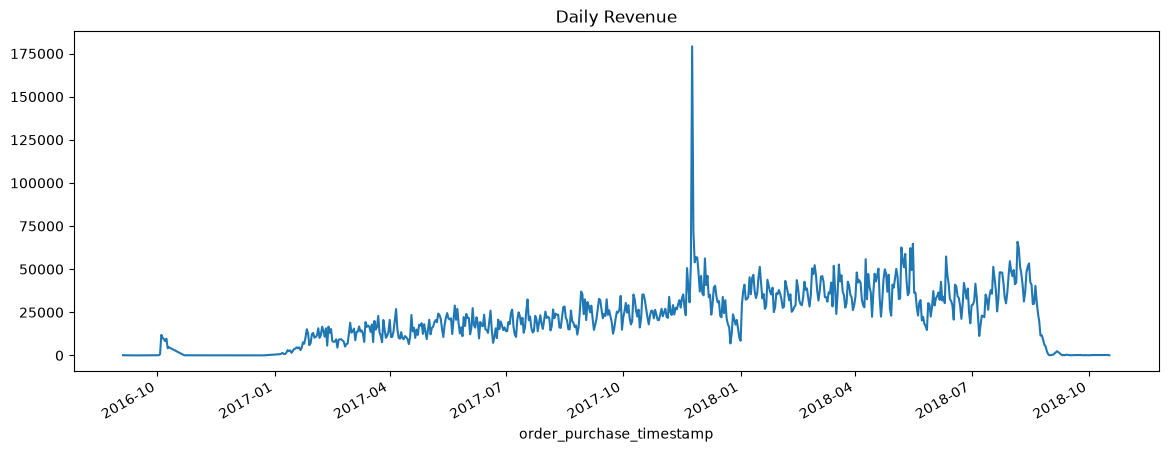

In [7]:
daily_revenue.plot(figsize=(14,5), title='Daily Revenue')
plt.show()

In [8]:
print(daily_revenue.index.min(), daily_revenue.index.max())

2016-09-04 00:00:00 2018-10-17 00:00:00


In [9]:
daily_revenue_clean = daily_revenue['2017-01-01':'2018-08-31']

In [10]:
daily_revenue_clean

order_purchase_timestamp
2017-01-05     707.27
2017-01-06     988.28
2017-01-07    1447.99
2017-01-08     809.63
2017-01-09     774.51
               ...   
2018-08-27    6229.95
2018-08-28    5216.72
2018-08-29    2381.83
2018-08-30     705.04
2018-08-31      63.89
Name: payment_value, Length: 604, dtype: float64

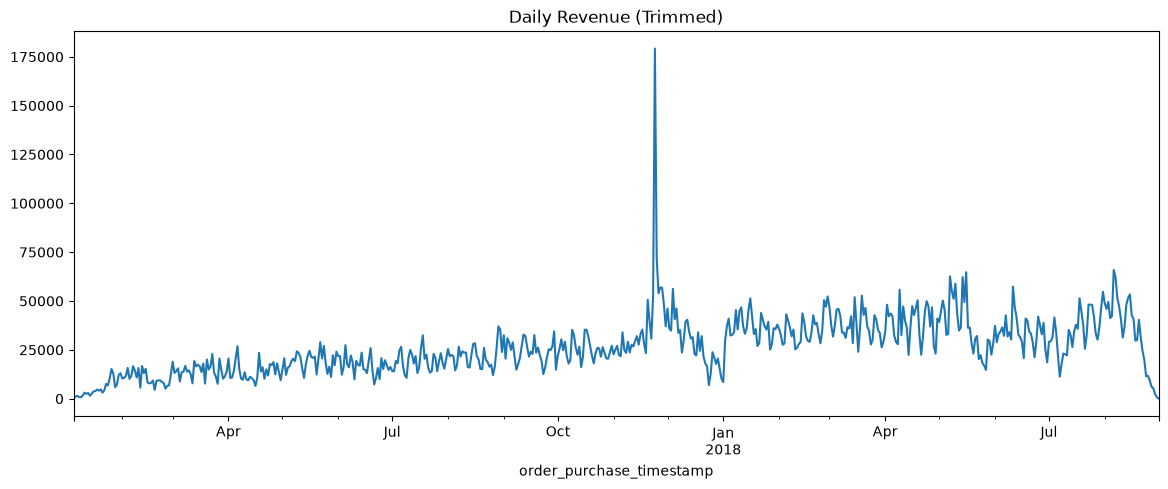

In [11]:
daily_revenue_clean.plot(figsize=(14,5), title='Daily Revenue (Trimmed)')
plt.show()

In [12]:
from sklearn.preprocessing import MinMaxScaler

values = daily_revenue_clean.values.reshape(-1, 1)

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(values)

scaled_values

array([[0.00359157],
       [0.00516027],
       [0.00772653],
       [0.00416298],
       [0.00396693],
       [0.00841416],
       [0.01673833],
       [0.01361423],
       [0.01585431],
       [0.00805795],
       [0.01388581],
       [0.02036635],
       [0.02137882],
       [0.02578759],
       [0.02275515],
       [0.0258696 ],
       [0.01691937],
       [0.02353701],
       [0.04181178],
       [0.0375726 ],
       [0.05789128],
       [0.08445013],
       [0.07167867],
       [0.0326349 ],
       [0.03961663],
       [0.06768042],
       [0.07233515],
       [0.05720286],
       [0.05924349],
       [0.06461734],
       [0.0875495 ],
       [0.05632225],
       [0.0645437 ],
       [0.09246219],
       [0.07947073],
       [0.06017926],
       [0.08714154],
       [0.0311745 ],
       [0.09276967],
       [0.07272793],
       [0.08510393],
       [0.04612419],
       [0.04320641],
       [0.04482446],
       [0.0516055 ],
       [0.02463914],
       [0.05076257],
       [0.051

In [13]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size, 0])
        y.append(data[i+window_size, 0])
    return np.array(X), np.array(y)

window_size = 30
X, y = create_sequences(scaled_values, window_size)

print(X.shape, y.shape)

(574, 30) (574,)


In [14]:
X

array([[0.00359157, 0.00516027, 0.00772653, ..., 0.05720286, 0.05924349,
        0.06461734],
       [0.00516027, 0.00772653, 0.00416298, ..., 0.05924349, 0.06461734,
        0.0875495 ],
       [0.00772653, 0.00416298, 0.00396693, ..., 0.06461734, 0.0875495 ,
        0.05632225],
       ...,
       [0.25803905, 0.3047303 , 0.27234549, ..., 0.0515815 , 0.03442108,
        0.02876488],
       [0.3047303 , 0.27234549, 0.25605559, ..., 0.03442108, 0.02876488,
        0.01293954],
       [0.27234549, 0.25605559, 0.27606769, ..., 0.02876488, 0.01293954,
        0.00357912]], shape=(574, 30))

In [15]:
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(X_train.shape, X_test.shape)

(459, 30) (115, 30)


In [16]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(X_train.shape, X_test.shape)

(459, 30, 1) (115, 30, 1)


In [17]:
X_train

array([[[0.00359157],
        [0.00516027],
        [0.00772653],
        ...,
        [0.05720286],
        [0.05924349],
        [0.06461734]],

       [[0.00516027],
        [0.00772653],
        [0.00416298],
        ...,
        [0.05924349],
        [0.06461734],
        [0.0875495 ]],

       [[0.00772653],
        [0.00416298],
        [0.00396693],
        ...,
        [0.06461734],
        [0.0875495 ],
        [0.05632225]],

       ...,

       [[0.17987141],
        [0.16161435],
        [0.15529932],
        ...,
        [0.27998236],
        [0.25360717],
        [0.18185487]],

       [[0.16161435],
        [0.15529932],
        [0.31104237],
        ...,
        [0.25360717],
        [0.18185487],
        [0.18441516]],

       [[0.15529932],
        [0.31104237],
        [0.18126655],
        ...,
        [0.18185487],
        [0.18441516],
        [0.34892099]]], shape=(459, 30, 1))

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, activation='relu', input_shape=(30, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

c:\Users\pande\OneDrive\Desktop\coding\customer-insights-platform\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0077 - val_loss: 0.0028
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0037 - val_loss: 0.0054
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0033 - val_loss: 0.0034
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0033 - val_loss: 0.0042
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0029 - val_loss: 0.0032
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0029 - val_loss: 0.0029
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0029 - val_loss: 0.0034
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0029 - val_loss: 0.0029
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0029 - val_loss: 0.0029
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0029 - val_l

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


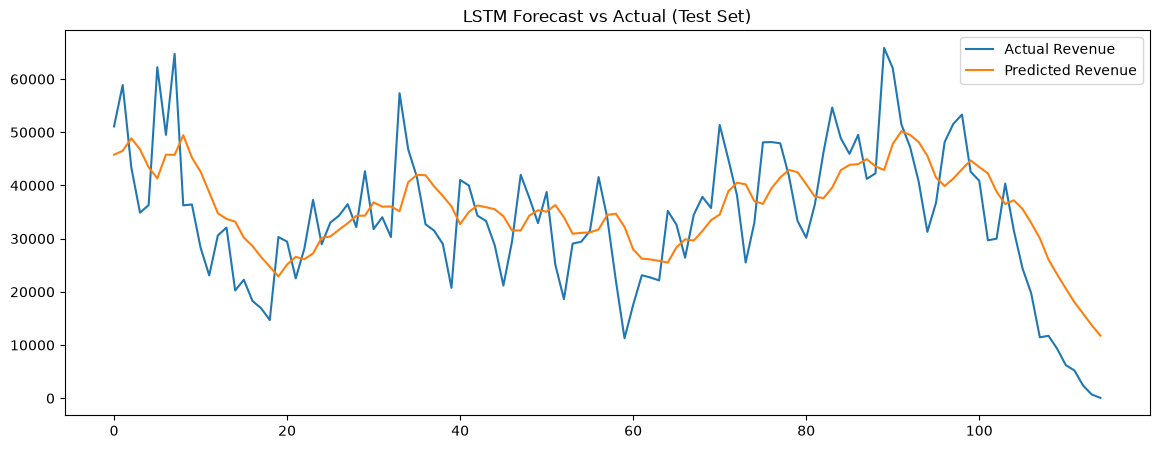

In [20]:
predictions_scaled = model.predict(X_test)

predictions = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(14,5))
plt.plot(y_test_actual, label='Actual Revenue')
plt.plot(predictions, label='Predicted Revenue')
plt.title('LSTM Forecast vs Actual (Test Set)')
plt.legend()
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_actual, predictions)
print(f"Mean Absolute Error: R$ {mae:.2f}")

Mean Absolute Error: R$ 7955.44


In [22]:
model.save('../models/forecast_model.h5')

import joblib
joblib.dump(scaler, '../models/forecast_scaler.pkl')

['../models/forecast_scaler.pkl']

In [23]:
model.save('../models/forecast_model.keras')